In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from nltk.corpus import stopwords
from wordcloud import WordCloud
from collections import Counter
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv("spam.csv", encoding="latin-1")

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [4]:
print(df.shape)
print(df.info())
print(df['label'].value_counts())

(5572, 2)
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB
None
label
ham     4825
spam     747
Name: count, dtype: int64


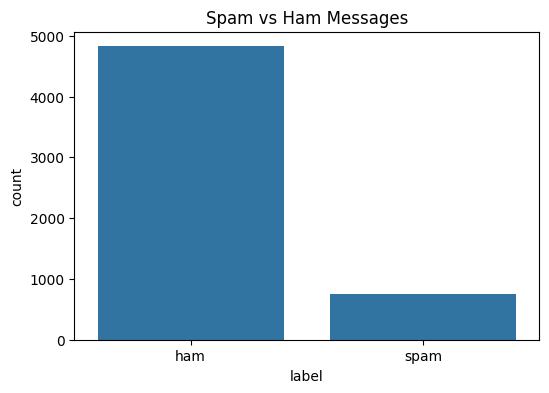

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Messages")
plt.show()

In [6]:
def clean_text(text):

    text = text.lower()

    text = ''.join(
        char for char in text
        if char not in string.punctuation
    )

    words = text.split()

    words = [
        word for word in words
        if word not in stopwords.words('english')
    ]

    return " ".join(words)

In [7]:
df['clean_message'] = df['message'].apply(clean_text)

print(df.head())

  label                                            message  \
0   ham  Go until jurong point, crazy.. Available only ...   
1   ham                      Ok lar... Joking wif u oni...   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3   ham  U dun say so early hor... U c already then say...   
4   ham  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry 2 wkly comp win fa cup final tkts 2...  
3                u dun say early hor u c already say  
4        nah dont think goes usf lives around though  


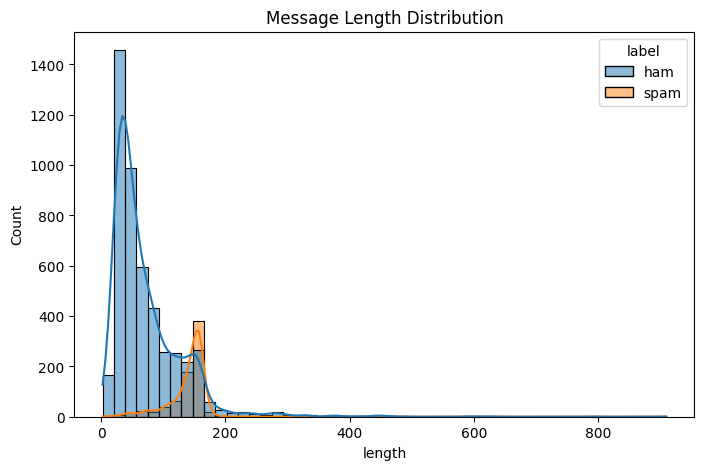

In [8]:
df['length'] = df['message'].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='length',
    hue='label',
    bins=50,
    kde=True
)

plt.title("Message Length Distribution")
plt.show()

In [9]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_message'])

y = df['label']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=41
)

In [11]:
model = MultinomialNB()

model.fit(X_train, y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [12]:
y_pred = model.predict(X_test)

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9730941704035875


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       958
        spam       1.00      0.81      0.89       157

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [17]:
print("Precision:", precision_score(y_test, y_pred, pos_label='spam'))
print("Recall   :", recall_score(y_test, y_pred, pos_label='spam'))
print("F1 Score :", f1_score(y_test, y_pred, pos_label='spam'))

Precision: 1.0
Recall   : 0.8089171974522293
F1 Score : 0.8943661971830986


In [18]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[958   0]
 [ 30 127]]
